<a href="https://colab.research.google.com/github/waelydz/ASD-Sense/blob/main/Model_MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib
!pip install kagglehub
!pip install scikit-learn seaborn

In [ ]:
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Success! TensorFlow found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(gpu)
else:
    print("Warning: No GPU detected. TensorFlow is using the CPU.")

I0000 00:00:1777504366.015006   10967 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Success! TensorFlow found 1 GPU(s):
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


W0000 00:00:1777504367.503085   10967 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:
import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub

DATASET_DIR = kagglehub.dataset_download('imranliaqat32/autism-spectrum-disorder-in-childrenhandgestures')
BINARY_DIR = os.path.join(DATASET_DIR, "binary_format_v2")

if not os.path.exists(BINARY_DIR):
    os.makedirs(os.path.join(BINARY_DIR, "yes_ASD"), exist_ok=True)
    os.makedirs(os.path.join(BINARY_DIR, "no_ASD"), exist_ok=True)

    for root, dirs, files in os.walk(DATASET_DIR):
        if "binary_format" in root:
            continue

        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                src_path = os.path.join(root, file_name)
                if "Non-ASD" in root:
                    shutil.copy(src_path, os.path.join(BINARY_DIR, "no_ASD", file_name))
                elif "ASD" in root:
                    shutil.copy(src_path, os.path.join(BINARY_DIR, "yes_ASD", file_name))

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    label_mode='binary',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    label_mode='binary',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 1708 files belonging to 2 classes.
Using 1367 files for training.


W0000 00:00:1777504368.496243   10967 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777504368.652141   10967 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
W0000 00:00:1777504369.116371   11209 subprocess_compilation.cc:241] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
W0000 00:00:1777504369.116404   11209 subprocess_compilation.cc:244] Used ptxas at /usr/local/cuda/bin/ptxas
W0000 00:00:1777504369.116450   11209 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.117441   11211 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas.

Found 1708 files belonging to 2 classes.
Using 341 files for validation.


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

def build_mobilenet():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

mobilenet_model = build_mobilenet()

W0000 00:00:1777504369.867545   11287 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.869288   11285 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.869972   11288 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.871636   11291 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.873934   11282 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.874696   11290 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504369.876094   11283 gpu_kernel_to_blob_pass.cc:190] Failed to co

In [ ]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'],
    jit_compile=False
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_mobilenet.keras", save_best_only=True)

print("\nStarting MobileNetV2 Training...")
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[checkpoint]
)


Starting MobileNetV2 Training...
Epoch 1/30


W0000 00:00:1777504372.542242   11204 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.800550   11354 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.809801   11353 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.810725   11358 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.810743   11362 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.830020   11357 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504372.831125   11359 gpu_kernel_to_blob_pass.cc:190] Failed to co

 4/43 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8548 - loss: 0.4385

W0000 00:00:1777504378.982117   11204 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777504379.031126   11204 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.8705 - loss: 0.3523 - val_accuracy: 0.9355 - val_loss: 0.2279
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9254 - loss: 0.2183 - val_accuracy: 0.9443 - val_loss: 0.1671
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9393 - loss: 0.1777 - val_accuracy: 0.9619 - val_loss: 0.1412
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9495 - loss: 0.1535 - val_accuracy: 0.9619 - val_loss: 0.1263
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9510 - loss: 0.1447 - val_accuracy: 0.9677 - val_loss: 0.1149
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9554 - loss: 0.1317 - val_accuracy: 0.9648 - val_loss: 0.1095
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9627 - loss: 0.1219 - val_accuracy: 0.9765 - val_loss: 0.1001
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9656 - loss: 0.1119 - val_accuracy: 0.9795 - val_loss: 

In [ ]:
best_mobilenet = tf.keras.models.load_model("best_mobilenet.keras")

print("\nEvaluating the Best Saved Model...")
val_loss, val_acc = best_mobilenet.evaluate(val_dataset)

print("-" * 30)
print(f"OFFICIAL FINAL ACCURACY: {val_acc * 100:.2f}%")
print(f"OFFICIAL FINAL LOSS:     {val_loss:.4f}")
print("-" * 30)


Evaluating the Best Saved Model...
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9824 - loss: 0.0648
------------------------------
OFFICIAL FINAL ACCURACY: 98.24%
OFFICIAL FINAL LOSS:     0.0648
------------------------------


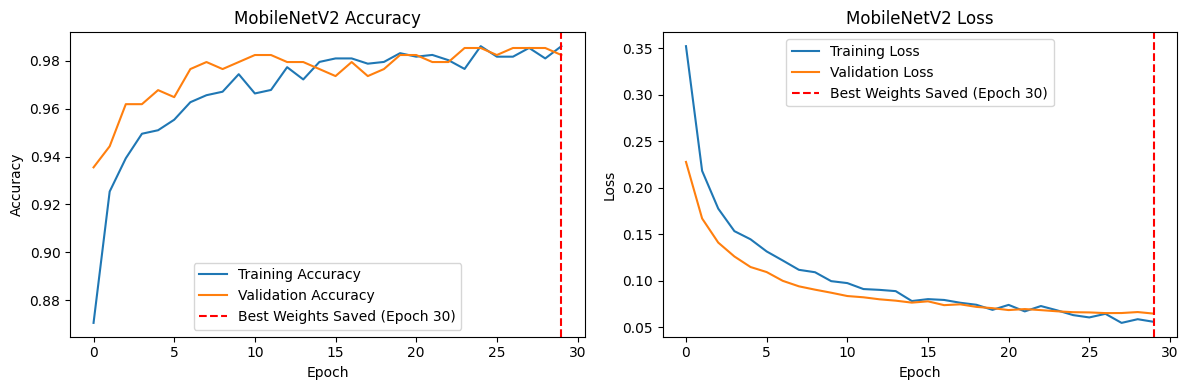

In [ ]:
import matplotlib.pyplot as plt
best_epoch = mobilenet_history.history['val_loss'].index(min(mobilenet_history.history['val_loss']))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Weights Saved (Epoch {best_epoch + 1})')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Weights Saved (Epoch {best_epoch + 1})')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("mobilenet_training_metrics.png")
plt.show()

Analyzing MobileNetV2...


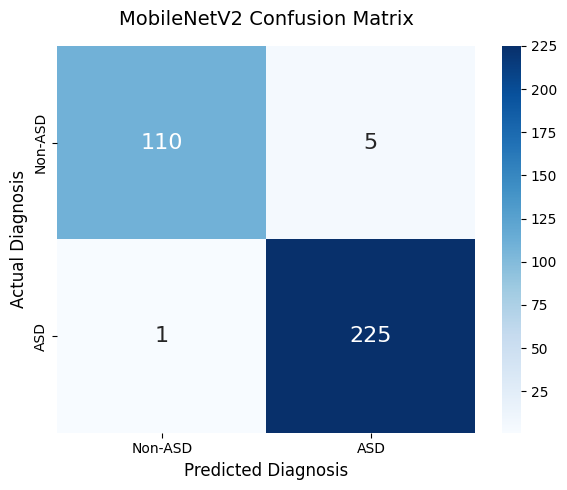


Detailed Metrics for MobileNetV2:
              precision    recall  f1-score   support

     Non-ASD       0.99      0.96      0.97       115
         ASD       0.98      1.00      0.99       226

    accuracy                           0.98       341
   macro avg       0.98      0.98      0.98       341
weighted avg       0.98      0.98      0.98       341



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def generate_evaluation_metrics(model, dataset, model_name):
    print(f"Analyzing {model_name}...")
    y_true = []
    y_pred_probs = []

    # Iterate through the dataset to extract exact labels and predictions
    for images, labels in dataset:
        y_true.extend(labels.numpy().flatten())
        preds = model.predict_on_batch(images)
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    # Convert probability percentages to strict 0 or 1 predictions
    y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

    # --- 1. Plot Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    # Using a clean blue color map for academic reporting
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-ASD', 'ASD'],
                yticklabels=['Non-ASD', 'ASD'],
                annot_kws={"size": 16})
    plt.title(f'{model_name} Confusion Matrix', fontsize=14, pad=15)
    plt.ylabel('Actual Diagnosis', fontsize=12)
    plt.xlabel('Predicted Diagnosis', fontsize=12)
    plt.tight_layout()

    # Automatically save a high-res copy for your Overleaf document
    file_name = f"{model_name.lower().replace(' ', '_')}_matrix.png"
    plt.savefig(file_name, dpi=300)
    plt.show()

    # --- 2. Print Classification Report ---
    print(f"\nDetailed Metrics for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=['Non-ASD', 'ASD']))

generate_evaluation_metrics(best_mobilenet, val_dataset, "MobileNetV2")